# Week 2 — California single-family sales exploration

This notebook explores every available monthly CRMLS sold-data file in `csv/`. The analysis is limited to California records with `PropertyType == Residential` and `PropertySubType == SingleFamilyResidence`, and to close dates in the available file months. It describes sold homes; it does not train a model or measure off-market accuracy.

The raw CSV files are expected in `csv/` and are not committed to Git. Only the columns needed for this exploration are loaded. `ListingKey` is used only to remove duplicate sale records, never as a valuation feature.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = Path('csv')
if not DATA_DIR.is_dir():
    raise FileNotFoundError('Place the CRMLS sold CSV files in the repository csv/ directory.')

sold_files = {}
for path in DATA_DIR.glob('CRMLSSold*.csv'):
    match = re.fullmatch(r'CRMLSSold(\d{6})(?:_filled)?\.csv', path.name)
    if match is None:
        raise ValueError(f'Unexpected sold CSV filename: {path.name}')
    month = pd.Period(match.group(1), freq='M')
    if month in sold_files:
        raise ValueError(f'Multiple sold CSV files found for {month}.')
    sold_files[month] = path
if not sold_files:
    raise FileNotFoundError('No CRMLS sold CSV files found in csv/.')
months = pd.PeriodIndex(sorted(sold_files), freq='M')
files = [sold_files[month] for month in months]

columns = [
    'ListingKey', 'CloseDate', 'ClosePrice', 'PropertyType', 'PropertySubType',
    'StateOrProvince', 'LivingArea', 'BedroomsTotal',
    'BathroomsTotalInteger', 'LotSizeSquareFeet', 'LotSizeAcres',
]
raw_sales = pd.concat(
    [pd.read_csv(path, usecols=columns, dtype={'ListingKey': 'string'}, low_memory=False) for path in files],
    ignore_index=True,
)
print(f'Loaded {len(raw_sales):,} records from {len(files)} monthly files ({months[0]} through {months[-1]}).')
display(pd.DataFrame({'Source file': [path.name for path in files]}))

Loaded 615,707 records from 28 monthly files (2024-01 through 2026-04).


,Source file
0,CRMLSSold202401_filled.csv
1,CRMLSSold202402.csv
2,CRMLSSold202403_filled.csv
3,CRMLSSold202404_filled.csv
4,CRMLSSold202405_filled.csv
5,CRMLSSold202406_filled.csv
6,CRMLSSold202407_filled.csv
7,CRMLSSold202408.csv
8,CRMLSSold202409.csv
9,CRMLSSold202410.csv


## Scope and preparation

The date and property-type filters define the EDA population. For repeated nonmissing `ListingKey` values, the record with the latest close date is retained; some repeated keys have revised dates or prices. Numeric parsing errors and impossible negative values become missing; zero bedrooms or bathrooms remain valid. Missing lot square footage is filled from positive lot acres when available (`1 acre = 43,560 square feet`). No price or size outlier is removed from the descriptive statistics.

In [2]:
scope_mask = (
    raw_sales['PropertyType'].eq('Residential')
    & raw_sales['PropertySubType'].eq('SingleFamilyResidence')
    & raw_sales['StateOrProvince'].astype('string').str.upper().eq('CA')
)
scoped_sales = raw_sales.loc[scope_mask].copy()
scoped_sales['CloseDate'] = pd.to_datetime(scoped_sales['CloseDate'], errors='coerce')
date_mask = scoped_sales['CloseDate'].dt.to_period('M').isin(months)
dated_sales = scoped_sales.loc[date_mask].sort_values('CloseDate', kind='mergesort').copy()
has_key = dated_sales['ListingKey'].notna()
duplicate_keys_removed = int(dated_sales.loc[has_key, 'ListingKey'].duplicated().sum())
sales = pd.concat(
    [dated_sales.loc[has_key].drop_duplicates('ListingKey', keep='last'), dated_sales.loc[~has_key]],
    ignore_index=True,
).sort_values('CloseDate', kind='mergesort').reset_index(drop=True)

numeric_columns = [
    'ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
    'LotSizeSquareFeet', 'LotSizeAcres',
]
for column in numeric_columns:
    sales[column] = pd.to_numeric(sales[column], errors='coerce').replace([np.inf, -np.inf], np.nan)
for column in ['ClosePrice', 'LivingArea', 'LotSizeSquareFeet', 'LotSizeAcres']:
    sales[column] = sales[column].where(sales[column].gt(0))
for column in ['BedroomsTotal', 'BathroomsTotalInteger']:
    sales[column] = sales[column].where(sales[column].ge(0))
sales['LotSizeSqFt'] = sales['LotSizeSquareFeet'].fillna(sales['LotSizeAcres'] * 43_560)
sales = sales.rename(columns={'BedroomsTotal': 'Bedrooms', 'BathroomsTotalInteger': 'Bathrooms'})

audit = pd.Series({
    'Raw rows loaded': len(raw_sales),
    'California residential single-family rows': len(scoped_sales),
    'Rows closed in available file months': len(dated_sales),
    'Duplicate listing keys removed': duplicate_keys_removed,
    'Final unique sales': len(sales),
}, name='Rows')
display(audit.to_frame())

,Rows
Raw rows loaded,615707
California residential single-family rows,309713
Rows closed in available file months,309713
Duplicate listing keys removed,264
Final unique sales,309449


In [3]:
monthly_sales = sales.groupby(sales['CloseDate'].dt.to_period('M')).size().reindex(months, fill_value=0)
monthly_median_price = sales.groupby(sales['CloseDate'].dt.to_period('M'))['ClosePrice'].median().reindex(months)
assert (monthly_sales > 0).all(), 'The filtered data must cover every available file month.'
display(pd.DataFrame({'Unique sales': monthly_sales, 'Median close price (USD)': monthly_median_price}))

eda_columns = ['ClosePrice', 'LivingArea', 'Bedrooms', 'Bathrooms', 'LotSizeSqFt']
summary = sales[eda_columns].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary['missing_n'] = sales[eda_columns].isna().sum()
summary['missing_pct'] = sales[eda_columns].isna().mean() * 100
display(summary[['count', 'missing_n', 'missing_pct', 'mean', 'std', 'min', '5%', '25%', '50%', '75%', '95%', '99%', 'max']].round(1))

,Unique sales,Median close price (USD)
2024-01,8321,799000.0
2024-02,9564,860000.0
2024-03,11633,880000.0
2024-04,12727,929000.0
2024-05,13805,936250.0
2024-06,12537,935000.0
2024-07,13361,925000.0
2024-08,12404,900000.0
2024-09,10893,890000.0
2024-10,12340,905000.0


,count,missing_n,missing_pct,mean,std,min,5%,25%,50%,75%,95%,99%,max
ClosePrice,309447.0,2,0.0,1297938.7,5645793.5,1.2,367360.0,625000.0,895000.0,1430000.0,3175000.0,6250000.0,9.895000e+08
LivingArea,309159.0,290,0.1,2034.9,1057.8,2.0,962.0,1377.0,1804.0,2422.0,3810.0,5649.0,1.237640e+05
Bedrooms,309449.0,0,0.0,3.5,1.0,0.0,2.0,3.0,3.0,4.0,5.0,6.0,4.500000e+01
Bathrooms,309399.0,50,0.0,2.6,1.2,0.0,1.0,2.0,2.0,3.0,5.0,6.0,1.750000e+02
LotSizeSqFt,303984.0,5465,1.8,1662276.9,619462518.4,0.0,3250.0,5663.0,7246.0,10350.0,49490.8,254442.0,3.402340e+11


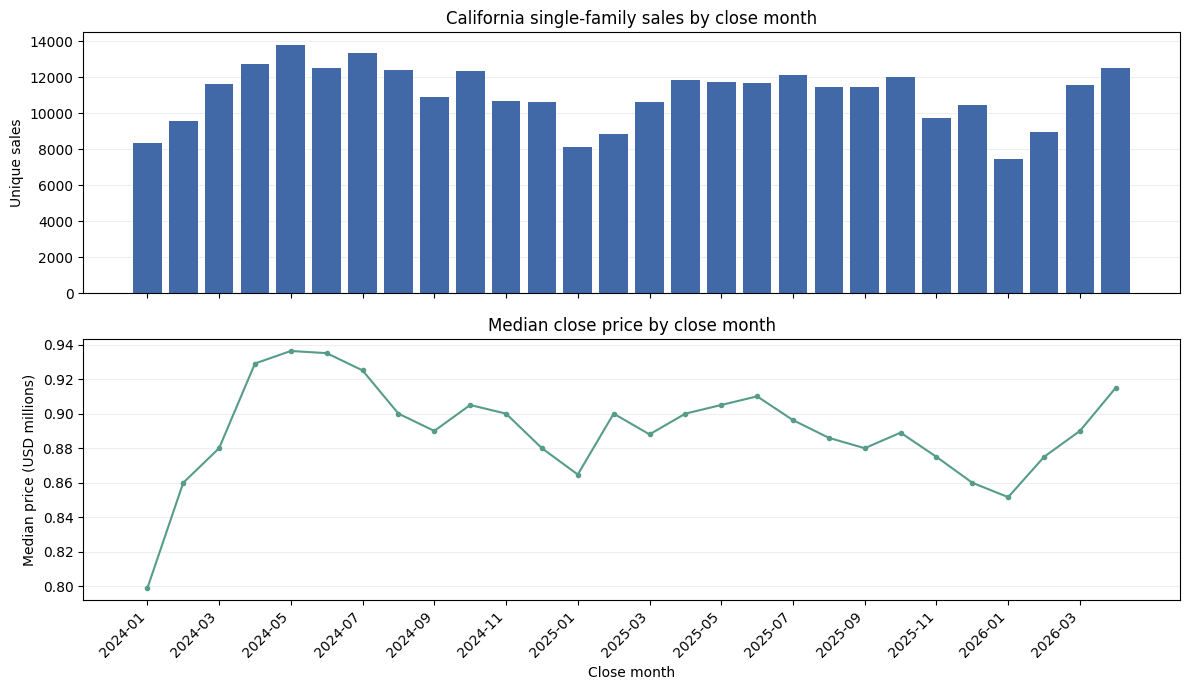

In [4]:
positions = np.arange(len(months))
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].bar(positions, monthly_sales.values, color='#4169A8')
axes[0].set(title='California single-family sales by close month', ylabel='Unique sales')
axes[1].plot(positions, monthly_median_price.values / 1_000_000, marker='o', markersize=3, color='#569C89')
axes[1].set(title='Median close price by close month', xlabel='Close month', ylabel='Median price (USD millions)')
tick_step = max(1, len(months) // 10)
axes[1].set_xticks(positions[::tick_step], months.astype(str)[::tick_step], rotation=45, ha='right')
for ax in axes:
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Distributions

The descriptive table above retains the full positive-value range. For readable linear-scale histograms, values above each variable's 99th percentile are omitted from that plot only. The second close-price histogram uses a log scale and includes all positive prices. The lot-size plot uses a log scale between the 1st and 99th percentiles. Bedroom and bathroom charts show 0–8; larger counts remain in the summary table.

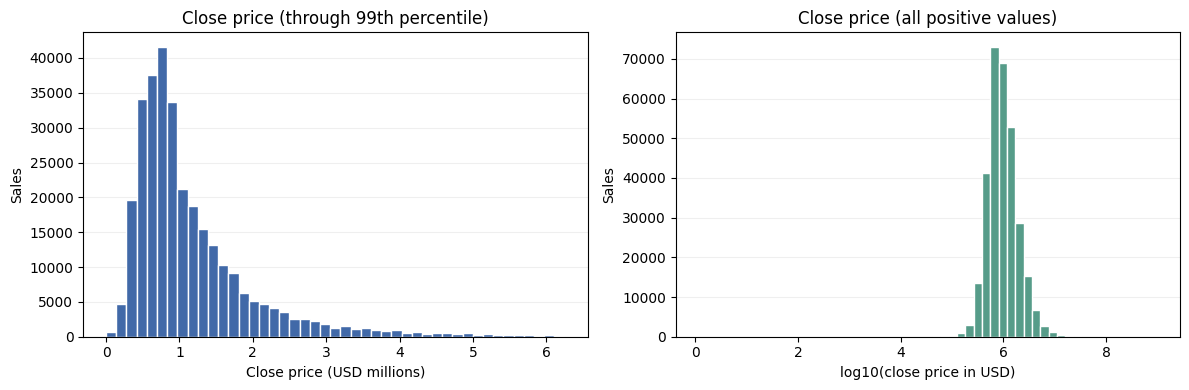

In [5]:
prices = sales['ClosePrice'].dropna()
price_p99 = prices.quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prices.loc[prices.le(price_p99)] / 1_000_000, bins=45, color='#4169A8', edgecolor='white')
axes[0].set(title='Close price (through 99th percentile)', xlabel='Close price (USD millions)', ylabel='Sales')
axes[1].hist(np.log10(prices), bins=55, color='#569C89', edgecolor='white')
axes[1].set(title='Close price (all positive values)', xlabel='log10(close price in USD)', ylabel='Sales')
for ax in axes:
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

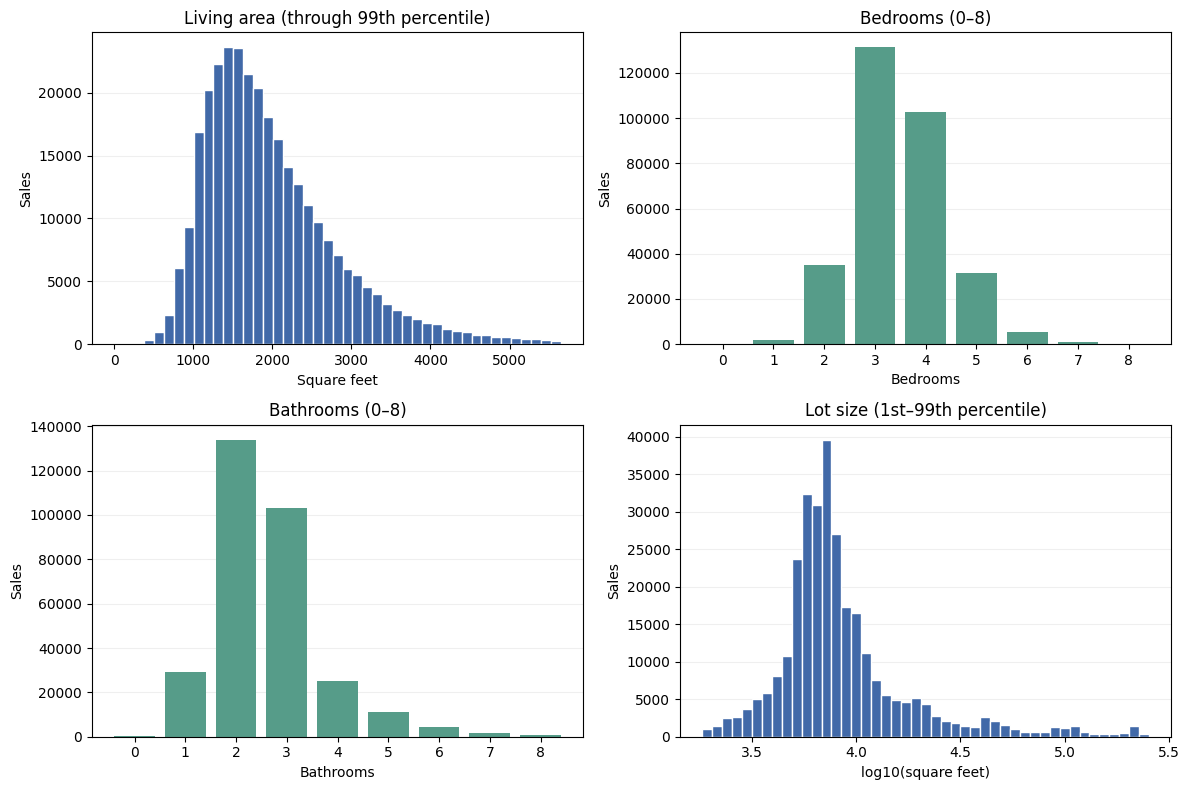

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
living_area = sales['LivingArea'].dropna()
living_area_cap = living_area.quantile(0.99)
axes[0, 0].hist(living_area.loc[living_area.le(living_area_cap)], bins=45, color='#4169A8', edgecolor='white')
axes[0, 0].set(title='Living area (through 99th percentile)', xlabel='Square feet', ylabel='Sales')
lot_size = sales['LotSizeSqFt'].dropna()
lot_low, lot_high = lot_size.quantile([0.01, 0.99])
lot_plot = lot_size.loc[lot_size.between(lot_low, lot_high)]
axes[1, 1].hist(np.log10(lot_plot), bins=45, color='#4169A8', edgecolor='white')
axes[1, 1].set(title='Lot size (1st–99th percentile)', xlabel='log10(square feet)', ylabel='Sales')
for ax, column, title in [
    (axes[0, 1], 'Bedrooms', 'Bedrooms (0–8)'),
    (axes[1, 0], 'Bathrooms', 'Bathrooms (0–8)'),
]:
    counts = sales.loc[sales[column].between(0, 8), column].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='#569C89')
    ax.set(title=title, xlabel=column, ylabel='Sales')
    ax.set_xticks(counts.index)
for ax in axes.flat:
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Interpretation and limits

The saved run covers 28 months (January 2024 through April 2026): 615,707 source rows become 309,449 unique California single-family sales after filtering and deduplication. The median close price is $895,000, compared with a $1.30 million mean, showing a strong right tail. Median living area is 1,804 square feet; the median home has 3 bedrooms, 2 bathrooms, and a 7,246-square-foot lot. Monthly sales range from 7,484 to 13,805; monthly median prices vary too, but this is not a constant-quality home-price index.

The extreme recorded price, bathroom, and lot-size maxima suggest potential source-data errors, so medians and quantiles are more informative than means for those fields. Missing-value counts describe the five requested variables after the stated lot-size fallback. These MLS closed sales are a selected sample of homes that sold, not a representative sample of every off-market California address. No list price, days-on-market, or contract-date field is used in the analysis.